📊 **Data Visualization**

In [1]:
import re
import nltk
import pandas as pd
import seaborn as sns
from wordcloud import STOPWORDS
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.probability import FreqDist
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords as nltk_stopwords

stopwords = set(nltk_stopwords.words('english'))

The dataset categorizes comments into several types based on the nature of offense:

Not Offensive: Comments that are neutral or non-offensive.

Untargeted Offense: Comments containing offensive language but not directed at a specific target.

Targeted Offense - Individual: Comments with offensive content aimed at specific individuals.

Targeted Offense - Group: Offensive comments directed at specific groups based on shared characteristics.

Targeted Offense - Other: Offensive comments targeted at other entities or categories not covered above.

In [2]:
df = pd.read_csv('./OLID_classifiers.csv')
df.head()

,text,label_A,label_B,label_C,type,label
0,user quit not heard knifecrime today,NOT,NaN,NaN,Not Offensive,0
1,celebration emancipation day urge emancipate r...,NOT,NaN,NaN,Not Offensive,0
2,user user would literal dream come true win es...,NOT,NaN,NaN,Not Offensive,0
3,brilliant news read doggy signed new contract ...,NOT,NaN,NaN,Not Offensive,0
4,user speaks truth relievedface,NOT,NaN,NaN,Not Offensive,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5780 entries, 0 to 5779
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     5780 non-null   object
 1   label_A  5780 non-null   object
 2   label_B  2885 non-null   object
 3   label_C  1456 non-null   object
 4   type     5780 non-null   object
 5   label    5780 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 271.1+ KB


In [4]:
print(df['type'].value_counts())

type
Not Offensive                    2895
Untargeted Offense               1429
Targeted Offense - Individual     987
Targeted Offense - Group          332
Targeted Offense - Other          137
Name: count, dtype: int64


Comments Distribution on Labels

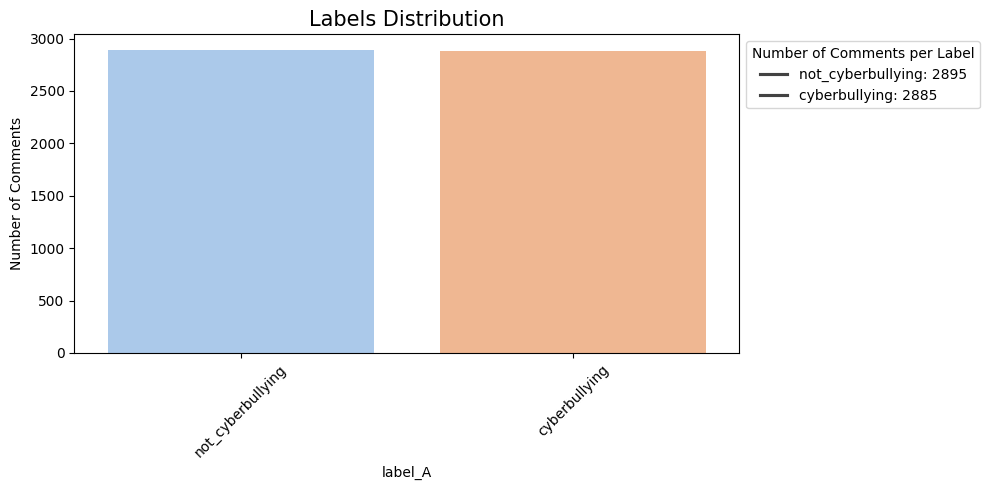

In [4]:
df['label_A'] = df['label_A'].replace({'OFF': 'cyberbullying', 'NOT': 'not_cyberbullying'})
type_counts = df['label_A'].value_counts()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette="pastel", legend=False)

plt.title("Labels Distribution", fontsize=15)
plt.ylabel("Number of Comments", fontsize=10)
plt.xticks(rotation=45)

legend_labels = [f"{label}: {count}" for label, count in type_counts.items()]
plt.legend(legend_labels, title="Number of Comments per Label", loc="upper left", bbox_to_anchor=(1, 1))  

plt.tight_layout()

plt.show()

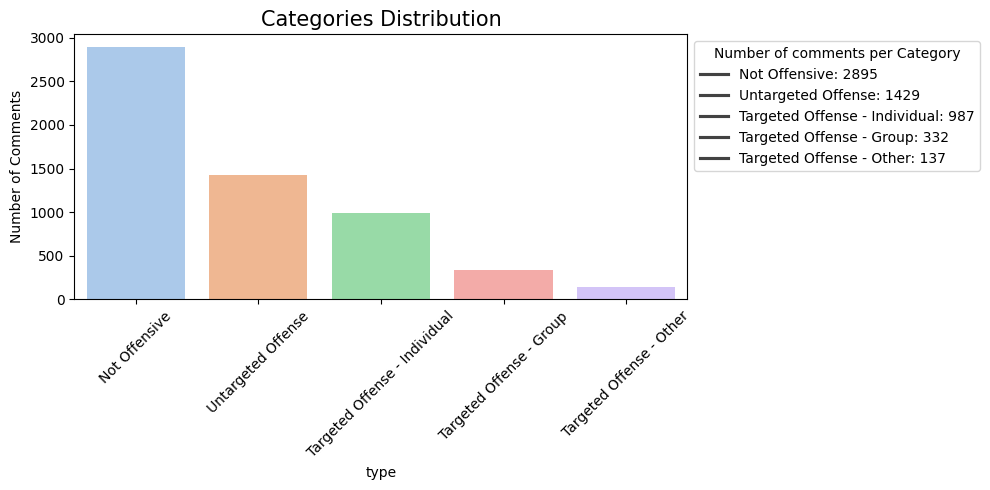

In [5]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette="pastel", legend=False)

plt.title("Categories Distribution", fontsize=15)
plt.ylabel("Number of Comments", fontsize=10)
plt.xticks(rotation=45)

legend_labels = [f"{label}: {count}" for label, count in type_counts.items()]
plt.legend(legend_labels, title="Number of comments per Category", loc="upper left", bbox_to_anchor=(1, 1))  

plt.tight_layout()

plt.show()

WordCloud - Visualizing the Most Common Words in Bullying Comments

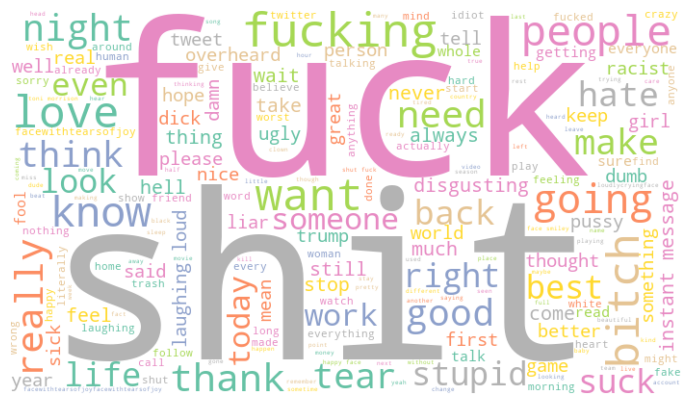

In [6]:
text = ' '.join(
    word for word in ' '.join(df['text'].astype(str).tolist()).split()
    if word.lower() != 'user' and word.lower() != 'significant' and len(word) > 3
)

wordcloud = WordCloud(width=700, height=400, background_color='white', colormap='Set2').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Word Frequency Analysis in Bullying Comments

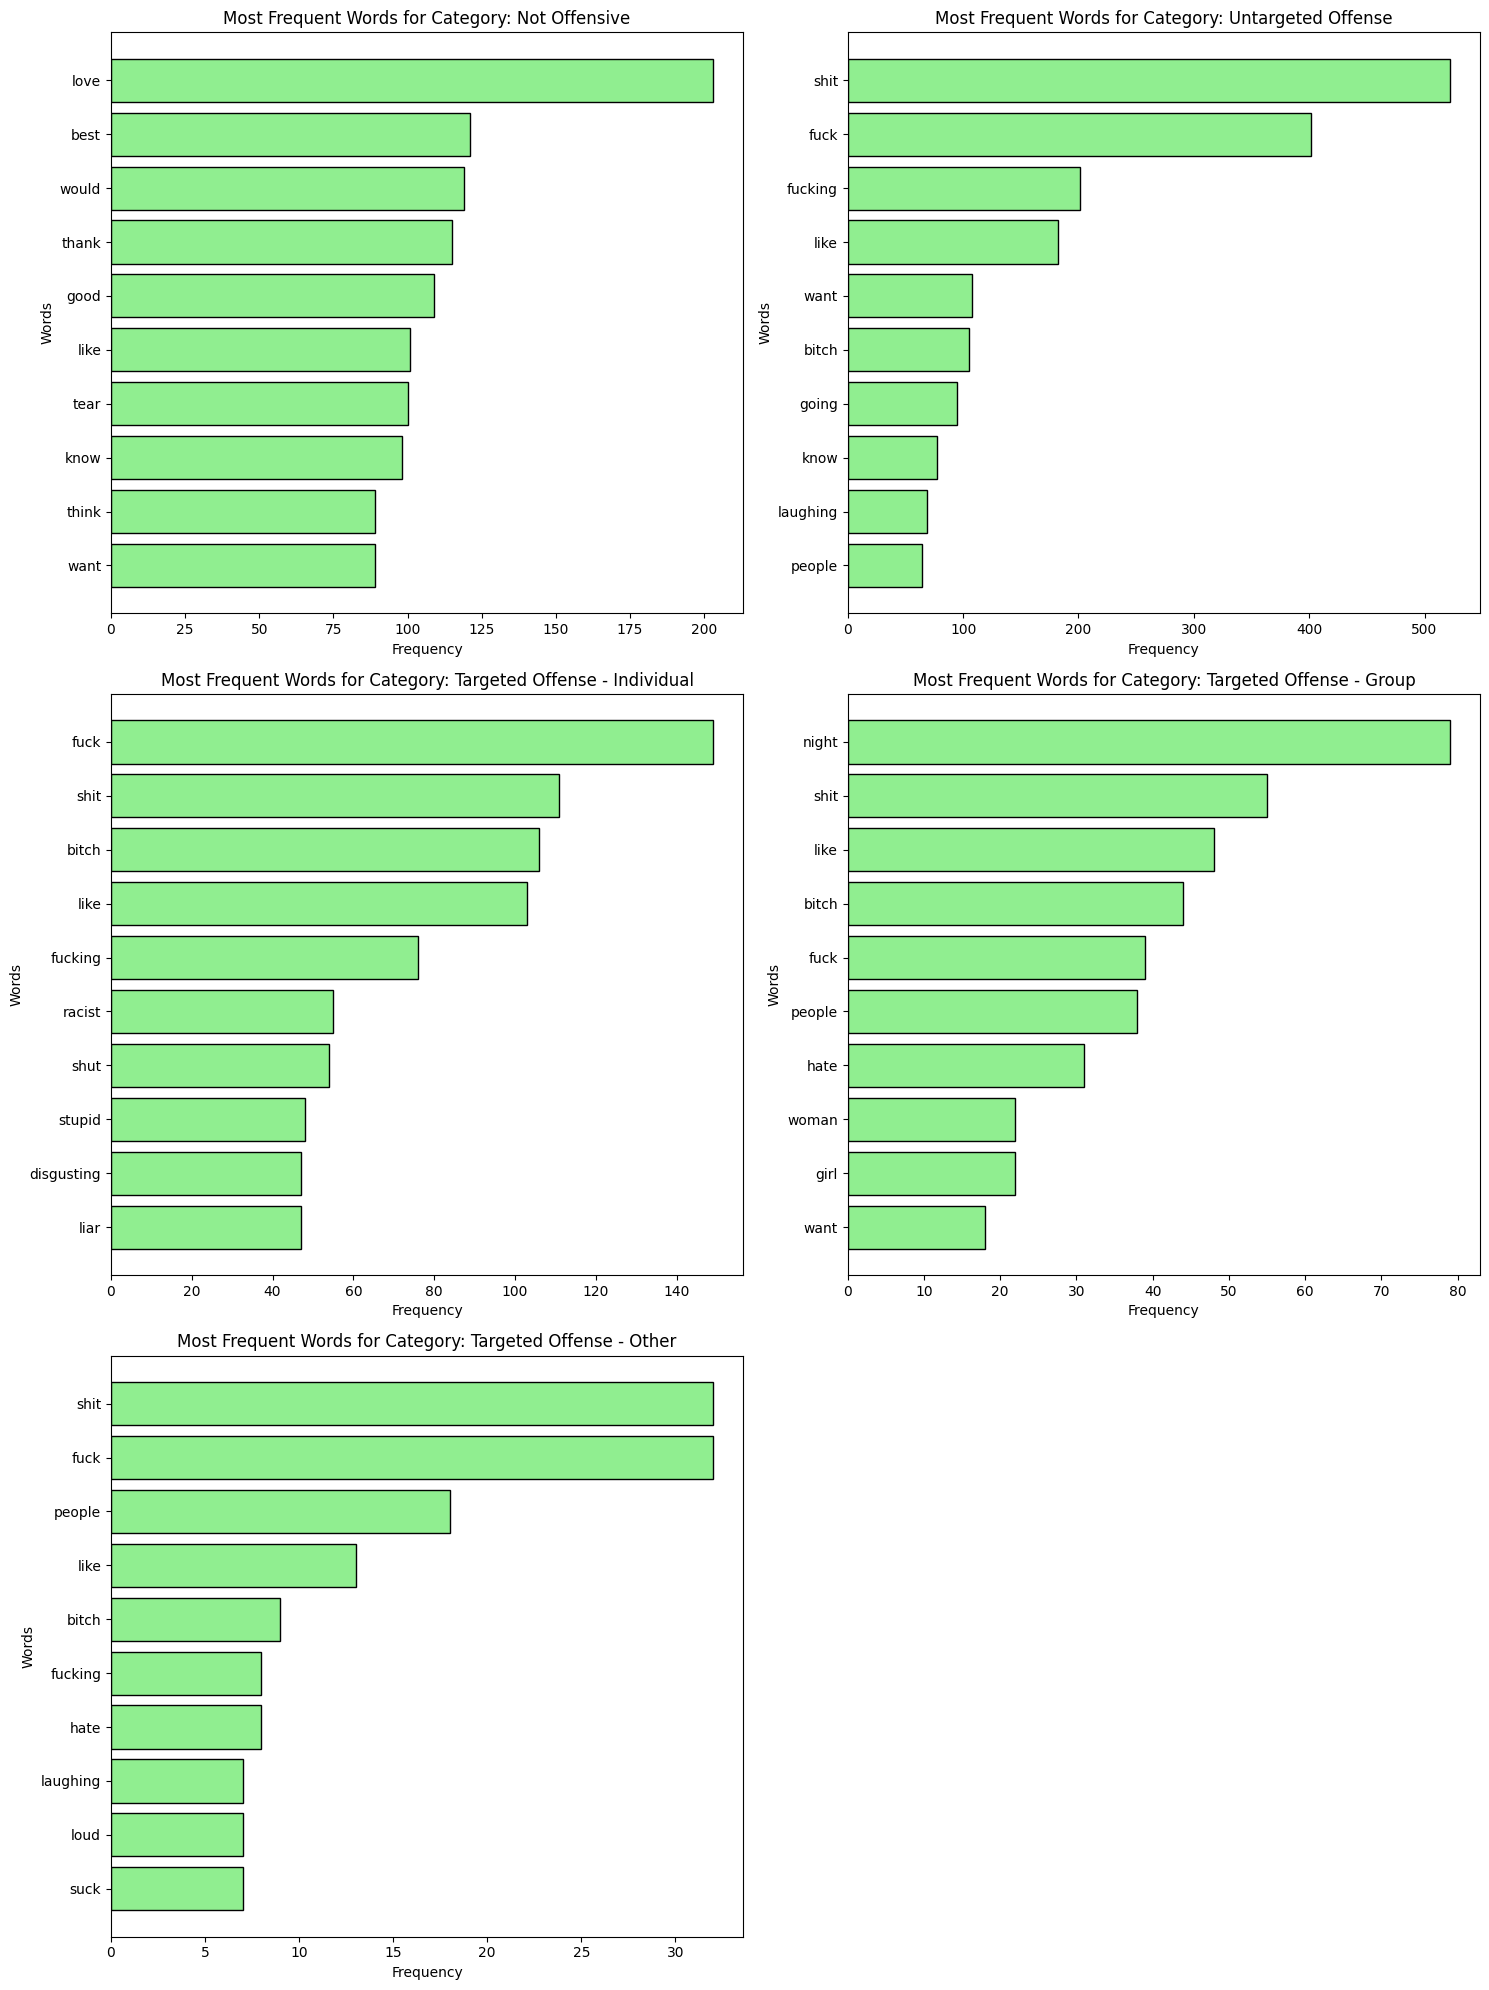

In [9]:
data = df 

labels = data['type'].unique()

fig, axs = plt.subplots(3, 2, figsize=(15, 20))
axs = axs.flatten()

for i, label in enumerate(labels):
    filtered_data = data[data['type'] == label]
    
    all_posts = ' '.join(filtered_data['text'].astype(str).tolist()).lower()
    
    all_posts = re.sub(r'[^\w\s]', '', all_posts)
    
    tokens = word_tokenize(all_posts, language='english')
    
    filtered_tokens = [word for word in tokens if len(word) > 3 and word not in stopwords and word != 'user' and word != 'significant' and word != 'really']
    
    freq_dist = FreqDist(filtered_tokens)
    
    num_top_words = 10 
    top_words = freq_dist.most_common(num_top_words)
    
    if not top_words:
        print(f"No words found for label {label}")
        continue
    
    words, frequencies = zip(*top_words)
    
    axs[i].barh(words[::-1], frequencies[::-1], color='#90ee90', edgecolor='black')
    axs[i].set_xlabel('Frequency')
    axs[i].set_ylabel('Words')
    axs[i].set_title(f'Most Frequent Words for Category: {label}')

for j in range(i+1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()


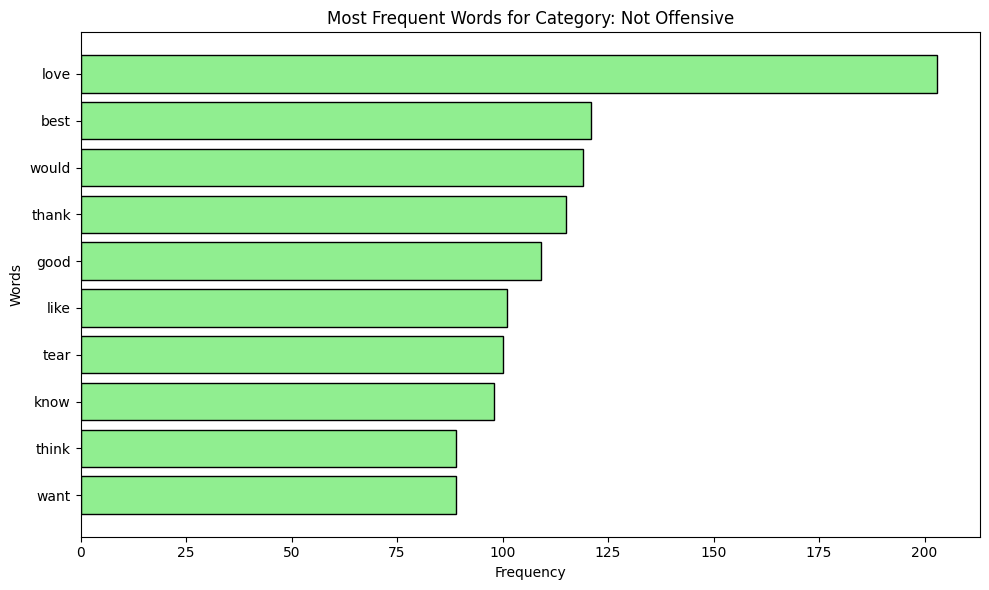

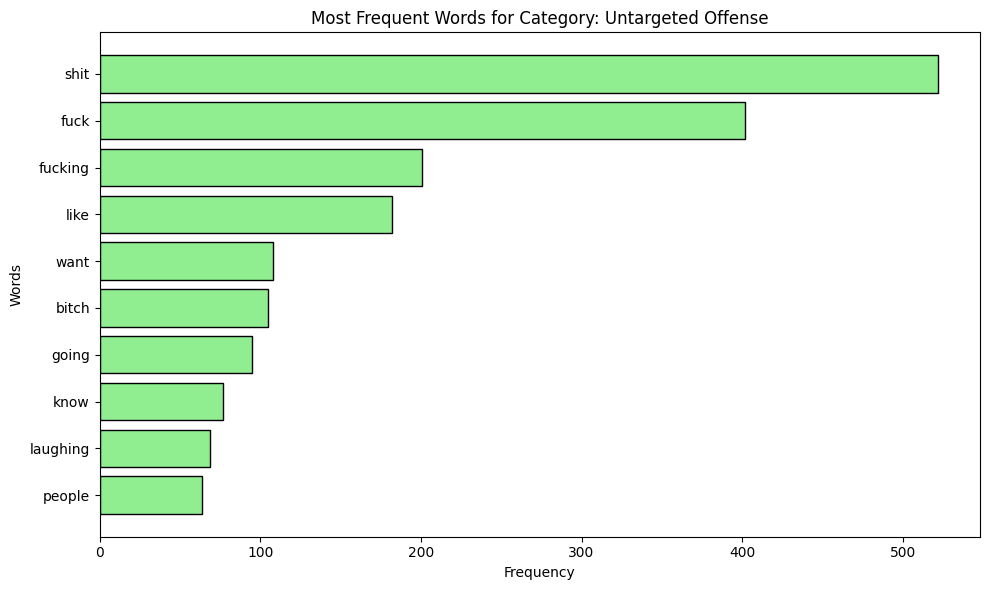

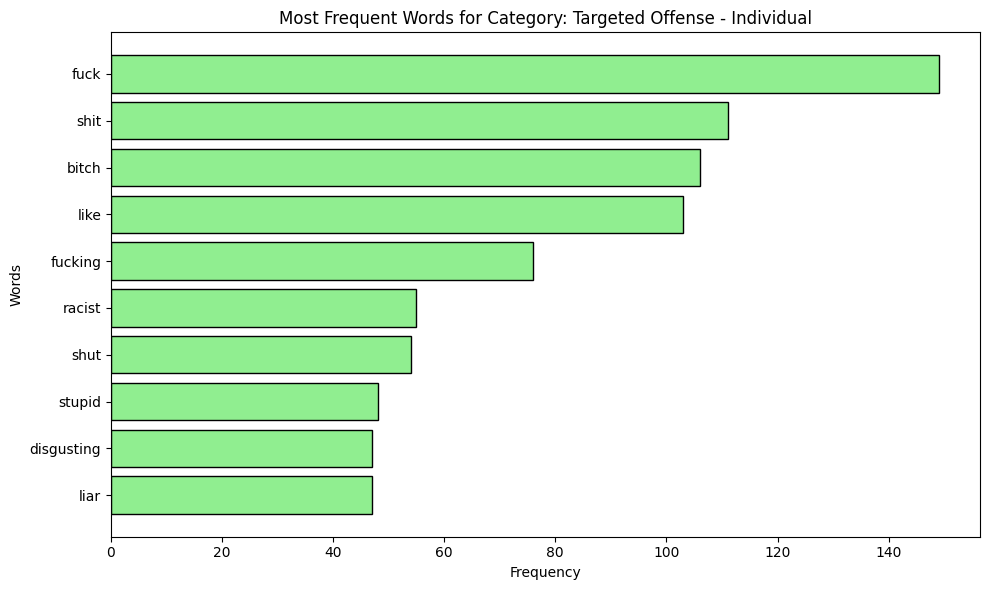

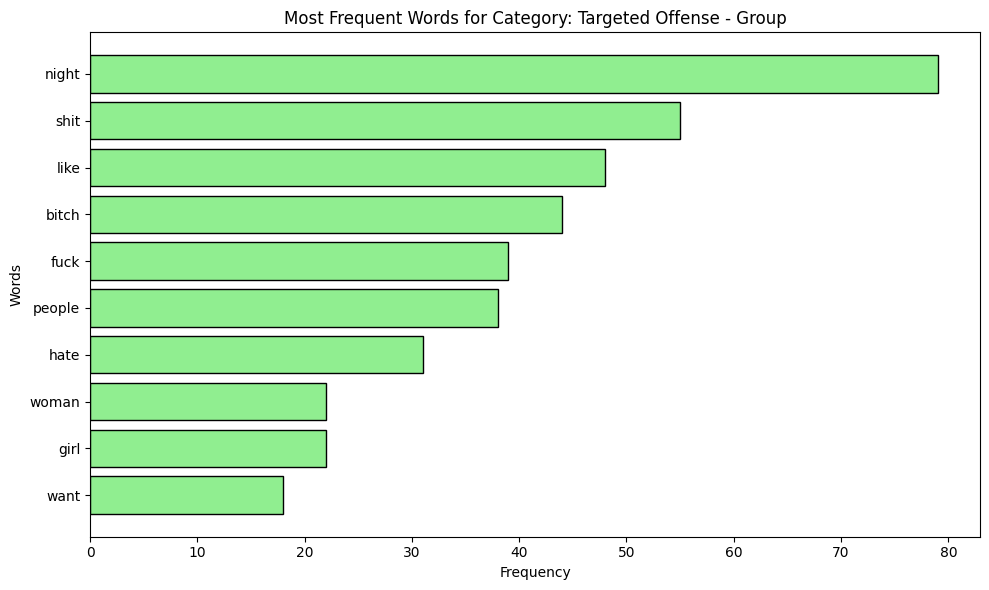

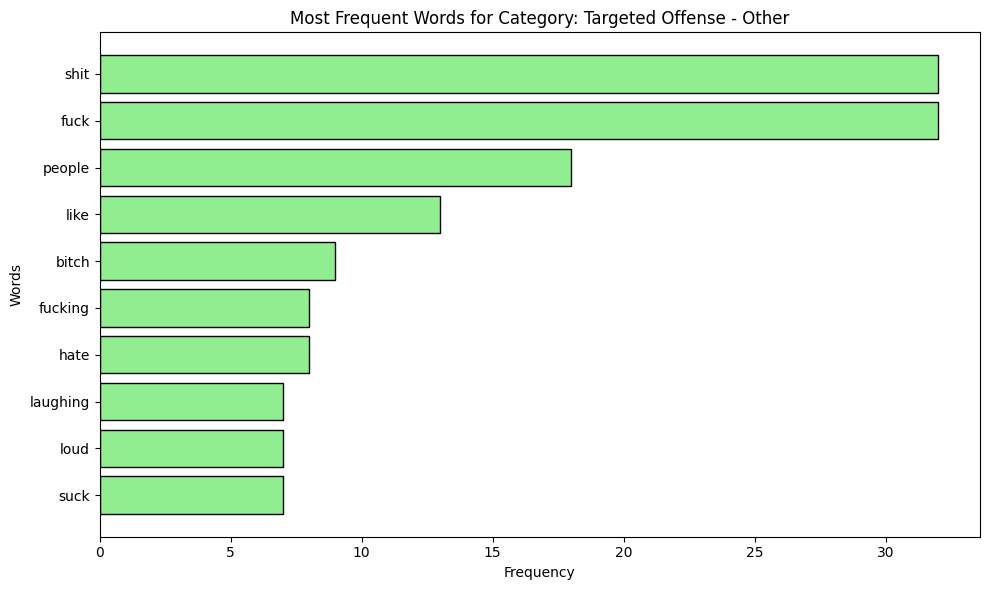

In [ ]:
import matplotlib.pyplot as plt
import re
from nltk import FreqDist, word_tokenize

labels = data['type'].unique()

fig, axs = plt.subplots(3, 2, figsize=(15, 15))
axs = axs.flatten()

for i, label in enumerate(labels):
    filtered_data = data[data['type'] == label]
    all_posts = ' '.join(filtered_data['text'].astype(str).tolist()).lower()
    all_posts = re.sub(r'[^\w\s]', '', all_posts)
    tokens = word_tokenize(all_posts, language='english')
    filtered_tokens = [word for word in tokens if len(word) > 3 and word not in stopwords and word != 'user' and word != 'significant' and word != 'really']
    freq_dist = FreqDist(filtered_tokens)

    num_top_words = 10
    top_words = freq_dist.most_common(num_top_words)

    if not top_words:
        print(f"No words found for label {label}")
        continue

    words, frequencies = zip(*top_words)
    axs[i].barh(words[::-1], frequencies[::-1], color='#90ee90', edgecolor='black')
    axs[i].set_xlabel('Frequency')
    axs[i].set_ylabel('Words')
    axs[i].set_title(f'Most Frequent Words for Category: {label}')

for j in range(i+1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()
